# Angiogram Video to Key-Frame Extraction and Angiogram Preprocessing Pipeline

 Overview

This notebook implements the **Angiogram Video → Key Frame → Angiogram Preprocessing** pipeline
designed for the *AI-Driven Coronary Disease Detection and Decision Support System*.

The goal is to:
- Convert angiogram DICOM/MP4 files into individual frames
- Automatically select diagnostically relevant key frames
- Apply standardized angiogram preprocessing
- Prepare outputs for the blockage detection and localization module


## Step 00 – Install & Import Dependencies

In [2]:
import cv2
import numpy as np
import pandas as pd
import json
from pathlib import Path
import pydicom

## Step 01: Upload Angiogram (DICOM or MP4)


In [24]:
angiogram_path = Path("C:/Users/User/Documents/IIT Stage 2/IIT Stage 2 Semester 1/CM2603  Data Science Group Project/Angiogram Videos/DICOM/Patient-0002")  # change if needed

print("Selected file:", angiogram_path)
print("Extension:", angiogram_path.suffix)
print("File exists:", angiogram_path.exists())

Selected file: C:\Users\User\Documents\IIT Stage 2\IIT Stage 2 Semester 1\CM2603  Data Science Group Project\Angiogram Videos\DICOM\Patient-0002
Extension: 
File exists: True


The system accepts angiogram data in **DICOM or MP4 format**, which is the standard
medical imaging format used in hospitals. This file may contain multiple frames
representing a complete angiography sequence.

## Step 02: Validate DICOM Format

In [25]:
def validate_input(file_path: Path) -> bool:

    try:
        ds = pydicom.dcmread(file_path)
        if hasattr(ds, "PixelData"):
            print("Valid DICOM image detected.")
            return True
    except:
        pass

    try:
        cap = cv2.VideoCapture(str(file_path))
        if cap.isOpened():
            cap.release()
            print("Valid MP4 video detected.")
            return True
    except:
        pass

    print("Unsupported format.")
    return False

is_valid = validate_input(angiogram_path)
print("Validation result:", is_valid)

Valid DICOM image detected.
Validation result: True


Before processing, the system validates whether the uploaded file is a valid
DICOM or MP4 file. This prevents corrupted or unsupported files from entering the
pipeline.

## Step 03: Read DICOM/MP4 Metadata & Frames

In [26]:
def read_angiogram(file_path: Path):

    # Try DICOM first
    try:
        print("Trying DICOM read...")
        ds = pydicom.dcmread(file_path)

        if hasattr(ds, "PixelData"):
            print("DICOM detected.")

            frames = ds.pixel_array.astype(np.float32)

            if len(frames.shape) == 2:
                frames = np.expand_dims(frames, axis=0)

            metadata = {
                "Source": "DICOM",
                "Modality": ds.get("Modality", "Unknown"),
                "NumberOfFrames": frames.shape[0]
            }

            return metadata, frames

    except Exception as e:
        print("DICOM read failed:", e)

    # Try MP4
    try:
        print("Trying MP4 read...")
        cap = cv2.VideoCapture(str(file_path))

        if cap.isOpened():
            print("MP4 detected.")

            frame_list = []

            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                frame_list.append(gray.astype(np.float32))

            cap.release()

            frames = np.array(frame_list)

            metadata = {
                "Source": "MP4",
                "Modality": "XA (Simulated)",
                "NumberOfFrames": frames.shape[0]
            }

            return metadata, frames

    except Exception as e:
        print("MP4 read failed:", e)

    raise ValueError("Unsupported or unreadable file format.")

metadata, frames = read_angiogram(angiogram_path)


Trying DICOM read...
DICOM detected.


Once validated, the DICOM or MP4 file is read to extract:
- Image metadata (useful for traceability)
- Multi-frame pixel data representing the angiogram sequence

## Step 04: Extract Individual Frames

In [27]:
def extract_frames(frame_array: np.ndarray):
    """
    Splits multi-frame DICOM pixel array into individual frames.
    """
    return [frame_array[i] for i in range(frame_array.shape[0])]


frame_list = extract_frames(frames)

print(f"Total frames extracted: {len(frame_list)}")

Total frames extracted: 41


Angiogram video files contain multiple frames captured over time.
Each frame is extracted and processed individually for quality analysis.

## Step 05: Frame Quality Analysis and Diagnostic Scoring

In this step, **each extracted frame is evaluated using quantitative image-quality metrics**
to determine how diagnostically informative it is. These metrics are later combined
into a single **diagnostic score**, which is used for key-frame selection.

### Step 5.1: Metric Computation Function

In [28]:
import cv2
import numpy as np

def compute_frame_quality_metrics(frame: np.ndarray):
    """
    Computes quality metrics for a single angiogram frame.
    """
    # Ensure grayscale (angiograms are usually grayscale already)
    if len(frame.shape) == 3:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        gray = frame.copy()

    # --- Mean Intensity ---
    mean_intensity = np.mean(gray)

    # --- Contrast (Standard Deviation) ---
    contrast = np.std(gray)

    # --- Edge Strength (Sobel Gradient Magnitude) ---
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    edge_strength = np.mean(np.sqrt(sobel_x**2 + sobel_y**2))

    # --- Noise Estimation (High-frequency variation) ---
    noise = np.std(gray - cv2.GaussianBlur(gray, (5, 5), 0))

    return {
        "mean_intensity": mean_intensity,
        "contrast": contrast,
        "edge_strength": edge_strength,
        "noise": noise
    }


### Step 5.2: Apply Metrics to All Frames

In [29]:
frame_metrics = []

for idx, frame in enumerate(frame_list):
    metrics = compute_frame_quality_metrics(frame)
    metrics["frame_index"] = idx
    frame_metrics.append(metrics)

frame_metrics[:3]  # Preview first few frames


[{'mean_intensity': np.float32(1603.6566),
  'contrast': np.float32(516.63306),
  'edge_strength': np.float64(186.58028430326877),
  'noise': np.float32(17.193274),
  'frame_index': 0},
 {'mean_intensity': np.float32(1813.2534),
  'contrast': np.float32(580.56555),
  'edge_strength': np.float64(196.92966240130244),
  'noise': np.float32(17.72289),
  'frame_index': 1},
 {'mean_intensity': np.float32(1740.7133),
  'contrast': np.float32(553.9567),
  'edge_strength': np.float64(162.9285215909865),
  'noise': np.float32(13.646913),
  'frame_index': 2}]

### Step 5.3: Diagnostic Score Computation

In [30]:
def compute_diagnostic_score(metrics, w1=0.3, w2=0.3, w3=0.3, w4=0.1):
    """
    Computes a diagnostic score from frame quality metrics.
    """
    score = (
        w1 * metrics["mean_intensity"]
        + w2 * metrics["contrast"]
        + w3 * metrics["edge_strength"]
        - w4 * metrics["noise"]
    )
    return score


for m in frame_metrics:
    m["diagnostic_score"] = compute_diagnostic_score(m)


### Diagnostic Scoring Formulation

Each frame is assigned a diagnostic score based on a weighted combination
of the computed quality metrics.

Let:

- $( \mu $) = Mean intensity  
- $( \sigma $) = Contrast (standard deviation)  
- $( E $) = Edge strength  
- $( N $) = Noise estimate  

The diagnostic score $( S $) for a frame is defined as:

$[
S = w_1 \cdot \mu + w_2 \cdot \sigma + w_3 \cdot E - w_4 \cdot N
$]

Where:
- $( w_1, w_2, w_3, w_4 $) are empirically chosen weights
- Noise is subtracted to penalize low-quality frames

This formulation prioritizes frames with:
- Clear dye diffusion
- High vessel contrast
- Strong vessel edges
- Minimal noise


Unlike processing all frames equally, this approach ensures that:
- Redundant or low-quality frames are discarded
- Only diagnostically meaningful frames are selected
- Computational cost is reduced
- Downstream blockage detection models receive higher-quality inputs

This step significantly improves robustness and aligns the system with
real-world clinical angiogram interpretation.

## Step 06: Key Frame Selection

The selection process follows three principles:

1. **Ranking** – Frames are sorted by diagnostic score (highest first)
2. **Top-K Selection** – Only the best 3–5 frames are retained
3. **Temporal Spacing** – Frames too close in time are avoided to reduce redundancy

This ensures that the final set of frames is:
- Informative
- Diverse
- Computationally efficient

### Step 6.1: Convert Metrics to Structured Array

In [31]:
import pandas as pd

# Convert frame metrics to DataFrame for easier ranking
metrics_df = pd.DataFrame(frame_metrics)

# Sort frames by diagnostic score (descending)
metrics_df = metrics_df.sort_values(
    by="diagnostic_score", ascending=False
).reset_index(drop=True)

metrics_df.head()


,mean_intensity,contrast,edge_strength,noise,frame_index,diagnostic_score
0,1813.253418,580.565552,196.929662,17.722891,1,775.452362
1,1781.979492,559.961914,179.170182,14.337982,37,754.899715
2,1776.579956,560.215576,178.016655,14.166107,36,753.027082
3,1775.769653,551.679138,180.334434,14.531823,40,750.881767
4,1770.851074,557.177429,177.641799,14.168712,35,750.284238


### Step 6.2: Temporal Spacing Helper Function

In [32]:
def select_top_k_with_spacing(
    df,
    k=5,
    min_frame_gap=3
):
    """
    Selects top-K frames while enforcing minimum temporal spacing.

    Parameters:
    - df: DataFrame sorted by diagnostic score
    - k: number of frames to select
    - min_frame_gap: minimum frame index gap to avoid redundancy
    """
    selected_frames = []
    selected_indices = []

    for _, row in df.iterrows():
        frame_idx = row["frame_index"]

        # Check temporal spacing
        if all(abs(frame_idx - idx) >= min_frame_gap for idx in selected_indices):
            selected_frames.append(row)
            selected_indices.append(frame_idx)

        if len(selected_frames) == k:
            break

    return pd.DataFrame(selected_frames)


### Step 6.3: Select Key Diagnostic Frames

In [33]:
# Select top 3–5 key frames
K = 5
MIN_FRAME_GAP = 3

key_frames_df = select_top_k_with_spacing(
    metrics_df,
    k=K,
    min_frame_gap=MIN_FRAME_GAP
)

key_frames_df


,mean_intensity,contrast,edge_strength,noise,frame_index,diagnostic_score
0,1813.253418,580.565552,196.929662,17.722891,1.0,775.452362
1,1781.979492,559.961914,179.170182,14.337982,37.0,754.899715
3,1775.769653,551.679138,180.334434,14.531823,40.0,750.881767
6,1769.509888,556.218140,172.778696,13.935085,24.0,748.158484
8,1763.670044,553.383667,178.030327,14.245033,34.0,747.100684


### Formal Interpretation

Let $( F = \{f_1, f_2, \dots, f_n\} )$ be the set of all angiogram frames  
and \( S(f_i) \) be the diagnostic score of frame $( f_i )$.

The selected key-frame set $( K \subset F )$ satisfies:

$$K = \arg\max_{|K| \leq k} \sum_{f \in K} S(f)$$

subject to:

$[
| index(f_i) - index(f_j) | \geq d \quad \forall f_i, f_j \in K
]$

where:
- $( k )$ is the maximum number of frames (3–5)
- $( d )$ is the minimum temporal spacing constraint

This ensures optimal diagnostic coverage with minimal redundancy.


## Step 07: Apply Angiogram Image Preprocessing to Selected Key Frames

This step **reuses the angiogram preprocessing pipeline already implemented**
in the project and applies it **only to the selected key frames**.

The preprocessing includes:
- Grayscale conversion
- Resizing to a fixed resolution (512 × 512)
- Intensity normalization
- Top-hat morphological filtering for vessel enhancement



### Step 7.1: Extract Selected Frames by Index

In [34]:
import cv2
from skimage.morphology import white_tophat, disk

# Extract selected frame indices as integers
selected_frame_indices = key_frames_df["frame_index"].astype(int).tolist()

# Retrieve corresponding frames
selected_frames = [frame_list[idx] for idx in selected_frame_indices]

print(f"Number of selected frames: {len(selected_frames)}")


Number of selected frames: 5


### Step 7.2: Define Enhanced Top-Hat Filter

In [35]:
def enhanced_tophat_filter(img, kernel_ratio=0.04, apply_clahe=True):

    img = img.astype(np.uint8)

    k = int(img.shape[1] * kernel_ratio)
    k = max(15, k | 1)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k))

    white = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
    black = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)

    enhanced = cv2.add(img, white)
    enhanced = cv2.subtract(enhanced, black)

    if apply_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(enhanced)

    return enhanced

### Step 7.3: Define Angiogram Preprocessing Function

In [36]:
import cv2
import numpy as np

def preprocess_angiogram_frame(
    frame: np.ndarray,
    target_size=(512, 512),
    apply_augmentation=False
):
    """
    Preprocess a single angiogram frame using the
    SAME methodology as dataset preprocessing.

    Steps:
    1. Grayscale conversion
    2. Resize to 512x512
    3. Intensity normalization
    4. Enhanced Top-hat vessel enhancement
    5. Optional augmentation (training only)
    """

    # Grayscale
    if len(frame.shape) == 3:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        gray = frame.copy()

    # Resize
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)

    # Normalize to 0–255 uint8
    normalized = cv2.normalize(
        resized,
        None,
        alpha=0,
        beta=255,
        norm_type=cv2.NORM_MINMAX
    ).astype(np.uint8)

    # Vessel Enhancement (Top-hat + CLAHE)
    enhanced = enhanced_tophat_filter(
        normalized,
        kernel_ratio=0.04,
        apply_clahe=True
    )


    return enhanced

Grayscale: Angiograms are intensity-based images

Resize: Enforces consistent input dimensions

Normalization: Scales intensities to $[0,1]$

Top-hat filtering: Enhances thin, bright vessel structures

### Step 7.4: Apply Preprocessing to All Selected Frames

In [37]:
preprocessed_frames = [
    preprocess_angiogram_frame(frame)
    for frame in selected_frames
]

print(f"Preprocessed frames generated: {len(preprocessed_frames)}")


Preprocessed frames generated: 5


### Step 7.4: Display the key frames

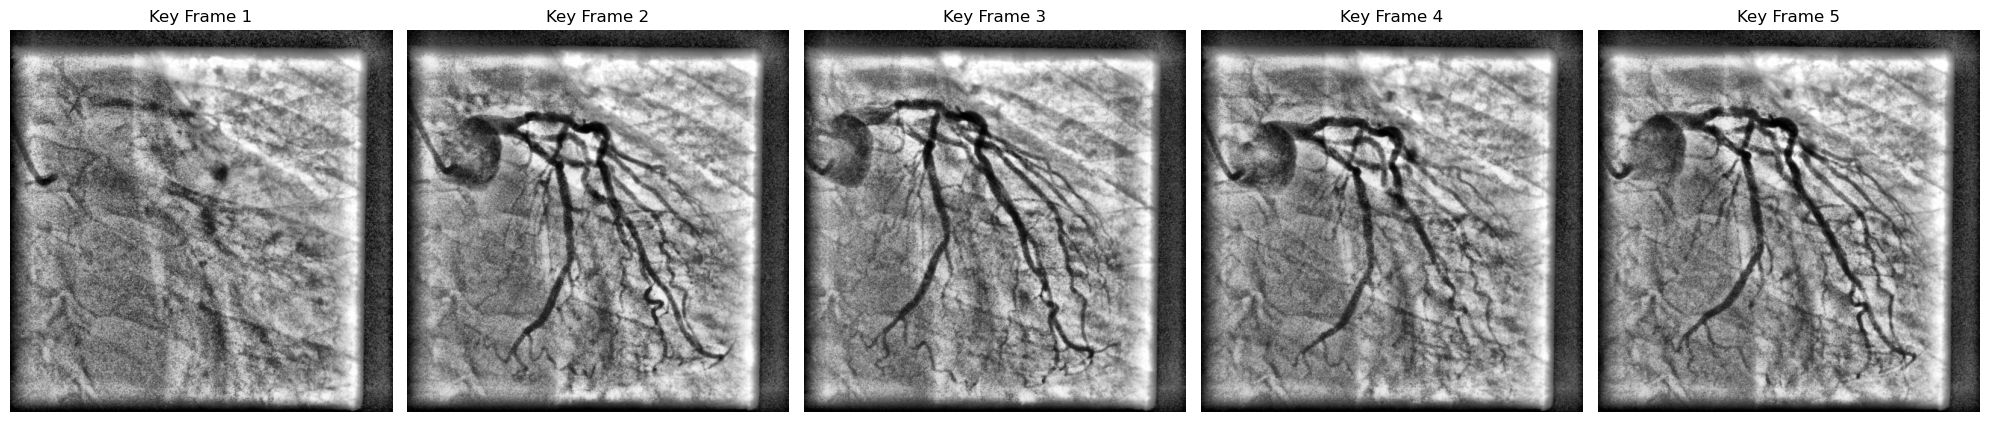

Selected frame indices: [1, 37, 40, 24, 34]


In [38]:
import matplotlib.pyplot as plt

# Number of frames
n = len(preprocessed_frames)

plt.figure(figsize=(4*n, 5))

for i in range(n):
    plt.subplot(1, n, i+1)
    plt.imshow(preprocessed_frames[i], cmap="gray", vmin=0, vmax=255)
    plt.title(f"Key Frame {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Selected frame indices:", selected_frame_indices)

The output of this step is a set of **preprocessed angiogram images** that:
- Represent the most diagnostically relevant frames
- Have enhanced vessel visibility
- Are standardized in size and intensity

These images are ready to be:
- Stored for traceability
- Passed to the Blockage Detection and Localization module

## Step 08: Store Preprocessed Angiogram Data and Metadata

After preprocessing the selected key angiogram frames, the final step is to
store the processed images along with relevant metadata.

This ensures:
- Traceability of frame selection
- Reproducibility of preprocessing
- Clean handover to the Blockage Detection and Localization module

All outputs are stored in a structured directory format suitable for
clinical review and downstream AI analysis.

The preprocessed data is stored using the following structure:

$patient_id -->frame_01.png, frame_02.png, frame_03.png,frame_04.png, frame_05.png, metadata.json$

This structure allows easy access to both image data and
the contextual information used during frame selection.

### Step 8.1: Create Output Directory

In [40]:
import uuid
from datetime import datetime
from pathlib import Path

output_root = Path("Preprocessed_Angiogram_Output")

# Automatic patient ID using file name + timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
patient_id = f"{angiogram_path.stem}_{timestamp}"

patient_dir = output_root / patient_id
patient_dir.mkdir(parents=True, exist_ok=True)

print("Output directory created at:", patient_dir)

Output directory created at: Preprocessed_Angiogram_Output\Patient-0002_20260214_194220


### Step 8.2: Save Preprocessed Frames

In [41]:
for i, frame in enumerate(preprocessed_frames, start=1):
    output_path = patient_dir / f"frame_{i:02d}.png"

    # Frame is already uint8 (0–255)
    cv2.imwrite(str(output_path), frame)

print(f"Saved {len(preprocessed_frames)} preprocessed frames.")

Saved 5 preprocessed frames.


## Step 8.3: Save Metadata as JSON

In [42]:
import json

output_metadata = {
    "patient_id": patient_id,
    "source": metadata["Source"],
    "number_of_original_frames": metadata["NumberOfFrames"],
    "selected_frame_indices": selected_frame_indices
}

metadata_path = patient_dir / "metadata.json"

with open(metadata_path, "w") as f:
    json.dump(output_metadata, f, indent=4)

print("Metadata saved successfully.")

Metadata saved successfully.
